# Multi-panel scenes and live serving

- `grid()` composes several `Scene3D`s into one subplot window, optionally with **linked cameras**. It
  returns a `pyvista.Plotter`, so we screenshot the plotter directly.
- `serve()` / `jupyter()` hand the scene to PyVista's **trame** integration for an interactive, streaming
  view in a notebook — the alternative to the frozen `screenshot`/`export_html` snapshot.

The panels show three **real** terrains: Mont Blanc, the Grand Canyon, and the Mariana Trench
(GEBCO bathymetry).

*DEMs: Copernicus WorldDEM-30 © DLR/Airbus (EU/ESA). Bathymetry: GEBCO 2020 Grid.*

---
*Data.* All layers below are built from **real data downloaded with
[earthlens](https://github.com/serapeum-org/earthlens)** and committed as small fixtures under
`examples/data/`; vector and 3-D layers are derived from those real rasters through **pyramids** (the GIS
engine), so nothing here is synthetic. Attributions are given per dataset.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

pv.OFF_SCREEN = True  # headless: every scene renders to an image, no interactive window

import pyramids  # import first: bootstraps pyramids' vendored GDAL
from pyramids.dataset import Dataset
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'real_dem_mont_blanc.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'


def show(scene, title=''):
    """Screenshot a Scene3D off-screen and show it inline, asserting the scene area is not blank."""
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


def show_image(img, title=''):
    """Show an already-captured RGB frame (e.g. from a pyvista Plotter) inline."""
    plt.figure(figsize=(7, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()
from digitalearth.three_d import grid

## `grid()` — three real terrains, linked cameras

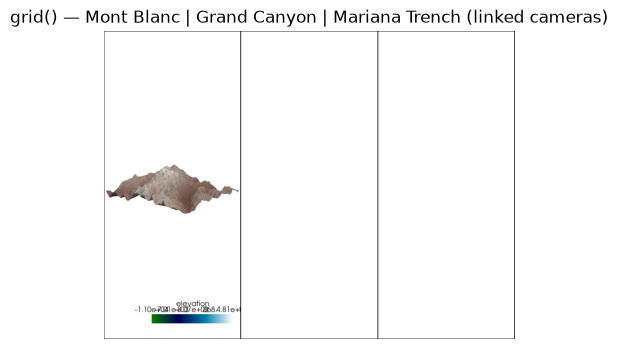

In [2]:
def terrain_panel(filename, cmap, zex):
    dem = Dataset.read_file(str(DATA / filename))
    s = Scene3D(off_screen=True)
    s.terrain(dem, z_exaggeration=zex, cmap=cmap)
    return s

plotter = grid(
    [terrain_panel('real_dem_mont_blanc.tif', 'terrain', 2.0),
     terrain_panel('real_dem_grand_canyon.tif', 'gist_earth', 2.0),
     terrain_panel('real_bathymetry.tif', 'ocean', 1.0)],
    shape=(1, 3), link=True, off_screen=True,
)
img = plotter.screenshot(return_img=True)
show_image(img, 'grid() — Mont Blanc | Grand Canyon | Mariana Trench (linked cameras)')
plotter.close()

## `serve()` / `jupyter()` — a live trame view

In a running Jupyter session `scene.serve()` returns a trame widget you can orbit, zoom and pick in real
time; `scene.jupyter('static')` switches PyVista's notebook backend to the screenshot used throughout this
gallery. Here we render the static snapshot, then construct the serve handle (its live canvas needs a
kernel/browser).

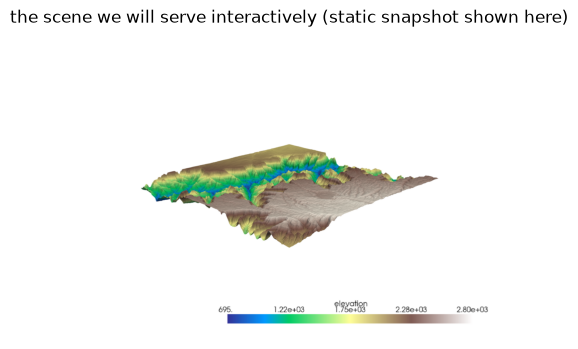

serve() returned: Widget — interactive in a live notebook


In [3]:
dem = Dataset.read_file(str(DATA / 'real_dem_grand_canyon.tif'))
scene = Scene3D(off_screen=True)
scene.terrain(dem, z_exaggeration=2.0, cmap='terrain')
scene.view('isometric')
show(scene, 'the scene we will serve interactively (static snapshot shown here)')
widget = scene.serve(mode='client')     # a trame widget — pan/zoom/pick live in a running notebook
print('serve() returned:', type(widget).__name__, '— interactive in a live notebook')
scene.close()